# Analisis Interaksi Pelanggan Lintas Channel: April 2026

## 1. Tujuan
- **Task 1:** menganalisis frekuensi interaksi pelanggan di semua channel (IM, Call, Ticket) selama April 2026 dan memantau tren harian/mingguan.
- **Task 2:** mengevaluasi kualitas layanan dan kepuasan pelanggan, lalu memberi rekomendasi berbasis temuan.

## 2. Data
| Dataset | Isi | Satuan 1 baris |
|---|---|---|
| im_records | Percakapan di platform pesan (web, Instagram, Facebook, WhatsApp) | 1 sesi percakapan |
| call_records | Panggilan telepon masuk dan keluar | 1 panggilan |
| tickets | Tiket dukungan, terutama dari email | 1 tiket |

## 3. Asumsi dan definisi
1. **Periode analisis:** 1-30 April 2026. File `tickets` mencakup Maret-Mei, sehingga difilter berdasarkan `Created`.
2. **Satuan interaksi:** 1 baris = 1 interaksi. Satu pelanggan yang menghubungi lewat beberapa channel dihitung terpisah.
3. **Tiket turunan:** tiket dengan `Channel` = `im` atau `call` (1.562 tiket) dianggap dibuat otomatis dari record IM/Call, sehingga **tidak dihitung dua kali** pada volume.
4. **Tiket tanpa kategori** (17%) rata-rata tertutup dalam sekitar 1 detik dan dianggap bukan interaksi layanan riil. Tiket ini **dikeluarkan dari metrik waktu respon dan penyelesaian**, tetapi tetap masuk hitungan volume.
5. **Pelanggan** dikenali dari nama, karena data tidak memiliki ID pelanggan.
6. **Abandon rate** = (Give up the queue + Customer quickly hang up + Queuing timeout) / total Call In.
7. **Respon pertama tiket** = `processing time` - `Created`; **waktu penyelesaian** = `Resolved time` - `Created`.
8. **SLA:** data tidak memuat target SLA, sehingga ambang **24 jam** untuk respon pertama tiket adalah asumsi analis.
9. **Tingkat kepuasan** dihitung dari pelanggan yang memberi penilaian (CSAT tidak wajib diisi).
10. **Minggu** dimulai hari Senin. Minggu 1-5 April dan 27-30 April hanya parsial.

<h1>SETUP DAN LOAD DATA

In [19]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

tickets      = pd.read_csv('tickets.csv')
call_records = pd.read_csv('call_records.csv')
im_records   = pd.read_csv('im_records.csv')

<H1> MENGENALI DATA

In [20]:
for name, d in [('tickets', tickets), ('call_records', call_records), ('im_records', im_records)]:
    print('=====', name, d.shape)
    print(d.head(3))
    print(d.isna().mean().round(2))

===== tickets (56361, 10)
  Internal Catagory_id_1                Customer         Assignee Channel  \
0                    NaN  Balidin Dongoran, S.T.  Darmana Mandala   email   
1                    NaN           Megan Mcclain  Darmana Mandala   email   
2                    NaN        Lantar Anggraini  Darmana Mandala   email   

        ID             Created Status Closed Resolved time processing time  
0  #151975  2026-05-21 9:26:30   open    NaN           NaN             NaN  
1  #151974  2026-05-21 9:26:30   open    NaN           NaN             NaN  
2  #151973  2026-05-21 9:24:56   open    NaN           NaN             NaN  
Internal Catagory_id_1    0.18
Customer                  0.00
Assignee                  0.00
Channel                   0.00
ID                        0.00
Created                   0.00
Status                    0.00
Closed                    0.06
Resolved time             0.03
processing time           0.01
dtype: float64
===== call_records (7323, 14)
  

<H1> DATA CLEANING</H1>

In [21]:
# 1. merapikan nama kolom
for d in (tickets, call_records, im_records):
    d.rename(columns={'Internal Catagory_id_1': 'category'}, inplace=True)

# 2. mengubah teks jadi tanggal
for col in ['Created', 'Closed', 'Resolved time', 'processing time']:
    tickets[col] = pd.to_datetime(tickets[col], errors='coerce')
call_records['Time'] = pd.to_datetime(call_records['Time'])
im_records['start']  = pd.to_datetime(im_records['Conversation start time'])

# 3. filter April 2026 (tiket mencakup Mar-Mei)
tickets = tickets[(tickets.Created >= '2026-04-01') & (tickets.Created < '2026-05-01')].copy()

# 4. ubah durasi "0:02:35" menjadi detik
to_sec = lambda s: pd.to_timedelta(s, errors='coerce').dt.total_seconds()
call_records['talk_s']    = to_sec(call_records['Processing Duration'])
call_records['queue_s']   = to_sec(call_records['Queuing time'])
im_records['first_resp_s'] = to_sec(im_records['First response time(hours/minutes/seconds)'])
im_records['dur_s']        = to_sec(im_records['Duration(hours/minutes/seconds)'])

# 5. waktu tiket dalam jam
tickets['first_resp_h'] = (tickets['processing time'] - tickets.Created).dt.total_seconds() / 3600
tickets['resolve_h']    = (tickets['Resolved time']   - tickets.Created).dt.total_seconds() / 3600

# 6. tandai tiket turunan dari IM/Call agar tidak dihitung dua kali
tickets['is_derived'] = tickets['Channel'].isin(['im', 'call'])

<H1> MEMBANGUN DATA MODEL (satu tabel fakta)

In [22]:
f_im = pd.DataFrame({
    'id': im_records['Dialogue ID'], 'channel_group': 'IM', 'source': im_records['Channel'],
    'dt': im_records['start'], 'customer': im_records['Customer'],
    'agent': im_records['Customer Service'], 'category': im_records['category'],
    'outcome': im_records['How the dialogue ends'], 'is_derived': False})

f_call = pd.DataFrame({
    'id': call_records['Call ID'], 'channel_group': 'Call', 'source': call_records['Call Type'],
    'dt': call_records['Time'], 'customer': call_records['Customer'],
    'agent': call_records['Agent'], 'category': call_records['category'],
    'outcome': call_records['Call Result'], 'is_derived': False})

f_tkt = pd.DataFrame({
    'id': tickets['ID'], 'channel_group': 'Ticket', 'source': tickets['Channel'],
    'dt': tickets['Created'], 'customer': tickets['Customer'],
    'agent': tickets['Assignee'], 'category': tickets['category'],
    'outcome': tickets['Status'], 'is_derived': tickets['is_derived']})

fact = pd.concat([f_im, f_call, f_tkt], ignore_index=True)
fact['category']   = fact['category'].fillna('Unclassified')
fact['date']       = fact['dt'].dt.date
fact['week_start'] = fact['dt'].dt.to_period('W-SUN').dt.start_time
fact['hour']       = fact['dt'].dt.hour
fact['weekday']    = fact['dt'].dt.day_name()

v = fact[~fact['is_derived']]   # data tanpa duplikasi, dipakai untuk volume
print(v.groupby('channel_group').size(), len(v))

channel_group
Call       7323
IM        15840
Ticket    20201
dtype: int64 43364


<h1> MENGHITUNG METRIK

In [23]:
# KPI
total      = len(v)
uniq_cust  = v['customer'].nunique()
per_cust   = v.groupby('customer').size()
repeat_pct = (per_cust >= 2).mean() * 100

# tren
daily  = v.groupby(['date', 'channel_group']).size().reset_index(name='jumlah')
weekly = v.groupby(['week_start', 'channel_group']).size().reset_index(name='jumlah')

# heatmap jam x hari
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
heat = v.groupby(['weekday', 'hour']).size().unstack(fill_value=0).reindex(order)

# kualitas call
ci = v[(v.channel_group == 'Call') & (v.source == 'Call In')]
abandon = ci['outcome'].isin(['Give up the queue', 'Customer quickly hang up', 'Queuing timeout'])
print('Abandon rate Call In:', round(abandon.mean() * 100, 1), '%')

# kualitas tiket (tiket tanpa kategori dikeluarkan dari metrik waktu)
tk = tickets[(~tickets['is_derived']) & (tickets['category'].notna())]
print('Median respon pertama (jam):', tk['first_resp_h'].median())
print('Median penyelesaian (jam)  :', tk['resolve_h'].median())
print('Dibalas <= 24 jam (%)      :', (tk['first_resp_h'] <= 24).mean() * 100)

# kepuasan IM
im_records['sat'] = im_records['Satisfaction - service evaluation']
print(im_records.groupby('category')['sat']
      .apply(lambda s: (s == 'Tidak Puas').sum() / s.notna().sum() * 100))

Abandon rate Call In: 10.1 %
Median respon pertama (jam): 21.941388888888888
Median penyelesaian (jam)  : 29.588472222222222
Dibalas <= 24 jam (%)      : 53.15836564270803
category
Complaint    43.856333
Feedback     13.333333
Inquiry      27.244094
Other        41.666667
Request      32.446809
Name: sat, dtype: float64


In [24]:
# ===== METRIK TAMBAHAN (IM, Call, Tiket, Pelanggan) =====
im = v[v.channel_group == 'IM']

print("IM - rata2 respon pertama (detik):", round(im_records['first_resp_s'].mean()))
print("IM - P90 respon pertama (detik)  :", round(im_records['first_resp_s'].quantile(.9)))
print("IM - rata2 durasi (menit)        :", round(im_records['dur_s'].mean() / 60, 1))
print("IM - % sesi 'system shutdown'    :", round((im['outcome'] == 'system shutdown').mean() * 100, 1))
print("IM - cara sesi berakhir:\n", im['outcome'].value_counts())

co = v[(v.channel_group == 'Call') & (v.source == 'Call Out')]
print("Call Out - % tersambung               :", round((co['outcome'] == 'Customer answer').mean() * 100, 1))
print("Call In - rata2 durasi bicara (menit) :",
      round(call_records.loc[call_records['Call Result'] == 'Agent answer', 'talk_s'].mean() / 60, 1))
print("Abandon rate per jam (%):\n", (ci.assign(a=abandon).groupby('hour')['a'].mean() * 100).round(1))

print("Tiket - P90 penyelesaian (jam) :", round(tk['resolve_h'].quantile(.9), 1))
print("Tiket - % > 48 jam             :", round((tk['resolve_h'].dropna() > 48).mean() * 100, 1))
print("Tiket - median penyelesaian per kategori (jam):\n", tk.groupby('category')['resolve_h'].median().round(1))
t_ok = tickets[~tickets['is_derived']]
print("Tiket - backlog (open/processing):", int(t_ok['Status'].str.contains('open|Processing', case=False).sum()))
print("Tiket - % tanpa kategori          :", round(t_ok['category'].isna().mean() * 100, 1))
print("Tiket - porsi 3 agen teratas (%)  :", round(t_ok['Assignee'].value_counts().head(3).sum() / len(t_ok) * 100, 1))

pc = v.groupby('customer').agg(n=('id', 'size'), ch=('channel_group', 'nunique'))
print("Pelanggan - % kontak >=2 kali :", round((pc.n >= 2).mean() * 100, 1))
print("Pelanggan - % lintas channel  :", round((pc.ch >= 2).mean() * 100, 1))
print("Pelanggan - jumlah >=5 kontak :", int((pc.n >= 5).sum()))

IM - rata2 respon pertama (detik): 26
IM - P90 respon pertama (detik)  : 60
IM - rata2 durasi (menit)        : 9.7
IM - % sesi 'system shutdown'    : 32.9
IM - cara sesi berakhir:
 outcome
customer service closed    10316
system shutdown             5217
customer close               262
transfer                      44
Name: count, dtype: int64
Call Out - % tersambung               : 18.8
Call In - rata2 durasi bicara (menit) : 3.6
Abandon rate per jam (%):
 hour
0      0.0
1      0.0
2      0.0
3      0.0
4      0.0
5      0.0
6      0.0
7      0.0
8      9.9
9     22.2
10     7.9
11     7.7
12    11.3
13     5.7
14     7.1
15     9.0
16    18.0
17    29.9
18     0.0
19     0.0
20     0.0
21     0.0
22     0.0
23     0.0
Name: a, dtype: float64
Tiket - P90 penyelesaian (jam) : 97.0
Tiket - % > 48 jam             : 35.2
Tiket - median penyelesaian per kategori (jam):
 category
Complaint    49.3
Feedback     48.8
Inquiry      17.8
Other        22.0
Request      42.6
Name: resolve_h, dty

<H1> VISUALISASI

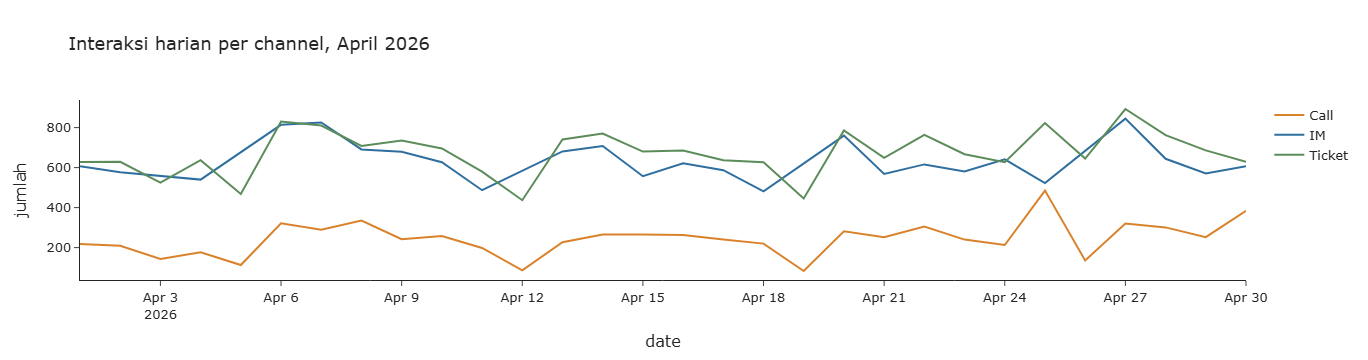

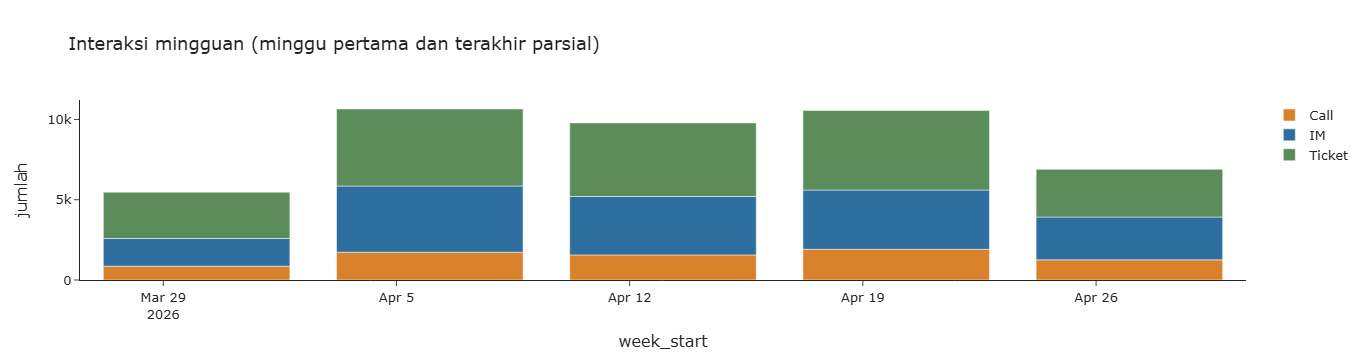

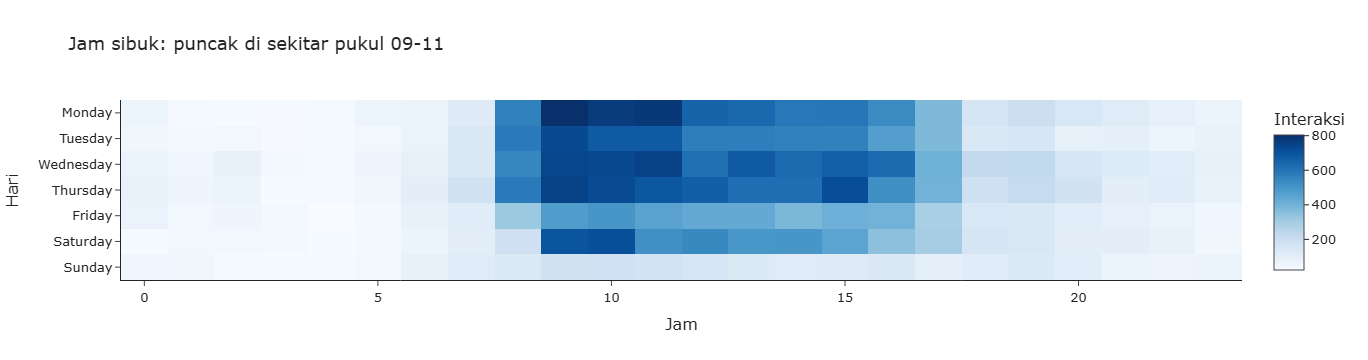

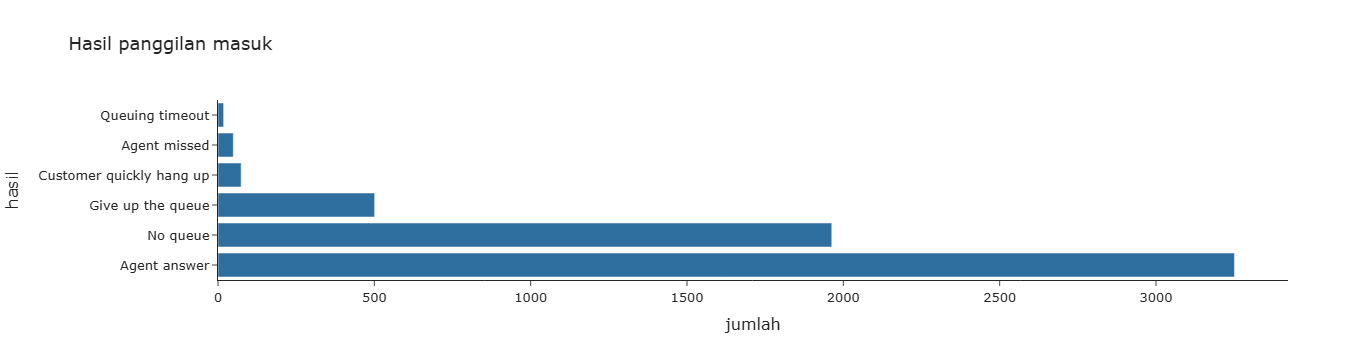

In [25]:
colors = {'IM': '#2f6f9f', 'Call': '#d9822b', 'Ticket': '#5b8c5a'}
base = dict(template='simple_white', font=dict(size=13), legend_title_text='')

# 1. tren harian
fig1 = px.line(daily, x='date', y='jumlah', color='channel_group',
               color_discrete_map=colors, title='Interaksi harian per channel, April 2026')
fig1.update_layout(**base); fig1.show()

# 2. tren mingguan
fig2 = px.bar(weekly, x='week_start', y='jumlah', color='channel_group',
              color_discrete_map=colors, title='Interaksi mingguan (minggu pertama dan terakhir parsial)')
fig2.update_layout(**base); fig2.show()

# 3. heatmap jam sibuk
fig3 = px.imshow(heat, color_continuous_scale='Blues', aspect='auto',
                 labels=dict(x='Jam', y='Hari', color='Interaksi'),
                 title='Jam sibuk: puncak di sekitar pukul 09-11')
fig3.update_layout(**base); fig3.show()

# 4. hasil Call In
res = ci['outcome'].value_counts().reset_index()
res.columns = ['hasil', 'jumlah']
fig4 = px.bar(res, x='jumlah', y='hasil', orientation='h', title='Hasil panggilan masuk')
fig4.update_traces(marker_color='#2f6f9f'); fig4.update_layout(**base); fig4.show()

## Temuan Task 1: Frekuensi dan Tren Interaksi

### Ringkasan volume
| Channel | Interaksi | Porsi |
|---|---|---|
| Ticket | 20.201 | 46,6% |
| IM | 15.840 | 36,5% |
| Call | 7.323 | 16,9% |
| **Total** | **43.364** | 100% |

- Terdapat **20.375 pelanggan unik** dengan rata-rata **2,13 interaksi per pelanggan**.
- **45,2%** pelanggan menghubungi lebih dari sekali dan **25,4%** memakai lebih dari satu channel. Sebanyak **1.532 pelanggan** menghubungi 5 kali atau lebih.

### Tren
- Volume mingguan relatif stabil di sekitar **9.800-10.700 interaksi** pada minggu penuh (6-12, 13-19, dan 20-26 April). Minggu 1-5 dan 27-30 April lebih rendah karena parsial.
- Hari tersibuk: **27 April (2.058)**, **6 April (1.966)**, dan **7 April (1.925)**.
- Jam sibuk berada pada jam kerja (puncak sekitar pukul 09.00-11.00, lihat heatmap). Aktivitas turun tajam setelah pukul 18.00.

### Metrik operasional tambahan
- **IM:** rata-rata respon pertama 26 detik (P90 60 detik), rata-rata durasi sesi 9,7 menit. Namun **32,9%** sesi berakhir "system shutdown".
- **Call In:** 5.856 panggilan; 55,5% dijawab agen; abandon rate **10,1%**; rata-rata durasi bicara 3,6 menit.
- **Call Out:** 1.467 panggilan; hanya **18,8%** tersambung ke pelanggan.
- **Tiket:** median respon pertama 21,9 jam, median penyelesaian 29,6 jam.
- **Kualitas data:** 17% tiket tanpa kategori; satu nama pelanggan tercatat memiliki 1.025 tiket yang tertutup otomatis (kemungkinan akun sistem/uji).

## Task 2: Kualitas Layanan dan Kepuasan Pelanggan

### Pendekatan
1. Mengukur kecepatan layanan tiap channel (respon, penyelesaian, antrean).
2. Mengukur hasil layanan (abandon, tersambung, sesi terputus).
3. Membaca kepuasan pelanggan (CSAT) per channel dan kategori.
4. Mencari pola: jam, kategori, dan channel yang bermasalah.
5. Menyusun rekomendasi yang dapat ditindaklanjuti.

### Temuan utama
| # | Temuan | Bukti |
|---|---|---|
| 1 | **Tiket lambat** | Hanya 53,2% tiket dibalas dalam 24 jam; median penyelesaian 29,6 jam; 35,2% butuh lebih dari 48 jam; P90 97 jam |
| 2 | **Complaint dan Request paling lama** | Median penyelesaian Complaint 49,3 jam dan Request 42,6 jam, dibanding Inquiry 17,8 jam |
| 3 | **Ketidakpuasan tinggi pada Complaint dan channel web** | % Tidak Puas (IM): Complaint 43,9% vs Inquiry 27,2%; web 39,9% vs Instagram 27,9% |
| 4 | **Sepertiga sesi IM berakhir "system shutdown"** | 5.217 sesi (32,9%) ditutup sistem, bukan agen atau pelanggan |
| 5 | **Abandon call memuncak pada jam tertentu** | Abandon Call In 10,1%; puncak pukul 17.00 (29,9%) dan 09.00 (22,2%) |
| 6 | **Panggilan keluar jarang tersambung** | Hanya 18,8% Call Out dijawab pelanggan |
| 7 | **Kontak berulang tinggi** | 45,2% pelanggan menghubungi lebih dari sekali; 1.532 pelanggan menghubungi 5 kali atau lebih |
| 8 | **Beban kerja tiket terpusat** | 3 agen teratas menangani 57,7% tiket |
| 9 | **Data kepuasan terbatas** | CSAT terisi hanya sekitar 10% di IM dan 3% di Call |

### Rekomendasi

**Prioritas tinggi (dampak cepat)**
1. **Tetapkan SLA tiket** (respon pertama 24 jam, Complaint 8 jam) dan pantau mingguan. Tambahkan prioritas otomatis untuk kategori Complaint.
2. **Atur jadwal agen telepon di jam rawan** (sekitar 09.00 dan 16.00-17.00). Sediakan callback otomatis dan informasi estimasi antrean untuk menekan abandon rate.
3. **Tinjau aturan "system shutdown" pada IM.** Cari tahu apakah pelanggan tidak terbalas atau sesi habis waktu, lalu tambahkan pesan tindak lanjut otomatis.

**Prioritas menengah**
4. **Perbaiki penanganan Complaint:** jalur eskalasi khusus, pelatihan agen, dan audit sampel percakapan yang dinilai Tidak Puas (terutama channel web).
5. **Kurangi kontak berulang:** buat FAQ atau balasan templat untuk Inquiry yang paling sering muncul, dan pantau repeat contact rate per kategori.
6. **Optimalkan Call Out:** atur jam panggilan, lakukan panggilan ulang, dan kirim pesan pemberitahuan sebelum menelepon.
7. **Seimbangkan beban tiket antar agen** agar tidak terpusat pada 3 agen.

**Perbaikan data dan pengukuran**
8. Wajibkan pengisian kategori pada tiket (saat ini 17% kosong).
9. Filter akun sistem/uji dari data pelaporan.
10. Naikkan response rate survei CSAT (sekarang sekitar 3-10%) dan tambahkan ID pelanggan agar kontak berulang dan lintas channel bisa dilacak akurat.
11. Tambahkan data yang belum ada: target SLA, status eskalasi, dan flag tiket yang dibuka kembali, untuk menghitung first contact resolution.

### Keterbatasan
- Pelanggan dikenali dari nama, sehingga nama yang sama bisa tergabung dan pelanggan yang sama dengan nama berbeda bisa terpisah.
- CSAT hanya diisi sebagian kecil pelanggan, sehingga hasil kepuasan bersifat **indikatif, bukan representatif**.
- Ambang SLA 24 jam adalah asumsi, bukan target resmi perusahaan.
- Analisis hanya mencakup April 2026, sehingga belum bisa menilai tren jangka panjang atau musiman.
- Hubungan antara tiket dan record IM/Call diasumsikan dari kolom channel dan belum diverifikasi dengan kunci penghubung.

### Langkah lanjutan
- Memantau KPI utama tiap minggu: abandon rate, % tiket dibalas dalam 24 jam, % Tidak Puas, dan repeat contact rate.